In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Sophia\Desktop\Python Homework\employee_preprocessing_dataset.csv")

df.head()

,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
0,1001,Sara,23,Cairo,Data,Bachelor,Junior,1,8500.0,7.8,160.0,F
1,1002,Omar,29,Alexandria,Sales,Master,Mid,5,14500.0,8.1,172.0,M
2,1003,Lina,31,Cairo,HR,Bachelor,Mid,7,13200.0,7.5,168.0,F
3,1004,Youssef,27,Giza,IT,Bachelor,Junior,3,11000.0,8.7,180.0,M
4,1005,Nour,35,Cairo,Data,Master,Senior,10,21000.0,9.0,176.0,F


In [2]:
# Q2. Display the last 5 rows
df.tail()

,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
33,1034,Omar,29,Alexandria,Sales,Master,Mid,5,14500.0,8.1,172.0,M
34,1035,Dina,29,Giza,HR,Master,Mid,5,NaN,8.2,171.0,F
35,1036,Mona,25,Cairo,Marketing,NaN,Junior,2,9500.0,7.4,162.0,F
36,1008,Ahmed,33,Cairo,IT,Master,Mid,8,17500.0,8.8,182.0,M
37,1021,Salma,28,Cairo,Data,Bachelor,Mid,4,15000.0,8.3,175.0,F


In [3]:
# Q3. Show the number of rows and columns
df.shape

(38, 12)

In [4]:
# Q4. Display all column names
df.columns

Index(['Employee_ID', 'Name', 'Age', 'City', 'Department', 'Education_Level',
       'Experience_Level', 'Years_Experience', 'Monthly_Salary',
       'Performance_Score', 'Monthly_Hours', 'Gender'],
      dtype='object')

In [5]:
# Q5. Display information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        38 non-null     int64  
 1   Name               38 non-null     object 
 2   Age                38 non-null     int64  
 3   City               37 non-null     object 
 4   Department         38 non-null     object 
 5   Education_Level    36 non-null     object 
 6   Experience_Level   38 non-null     object 
 7   Years_Experience   38 non-null     int64  
 8   Monthly_Salary     36 non-null     float64
 9   Performance_Score  37 non-null     float64
 10  Monthly_Hours      37 non-null     float64
 11  Gender             38 non-null     object 
dtypes: float64(3), int64(3), object(6)
memory usage: 3.7+ KB


In [6]:
# Q6. Summary statistics for numerical columns
df.describe()

# The mean Monthly_Salary(23,508.33) is much ihgher than the median(15,650), and the maximum salary is 250,000. This suggests the presence of a very large 
# salary outlier. 
# Monthly_Hours has a median of 175 but a maximum of 400, which suggests the presence of an external value. 

,Employee_ID,Age,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours
count,38.000000,38.000000,38.000000,36.000000,37.000000,37.000000
mean,1018.289474,32.131579,7.657895,23508.333333,8.181081,182.243243
std,10.397265,8.853679,7.286701,39706.360592,0.620859,38.605847
min,1001.000000,22.000000,0.000000,7800.000000,7.000000,156.000000
25%,1009.250000,27.250000,3.250000,10950.000000,7.800000,169.000000
50%,1018.500000,29.500000,5.500000,15650.000000,8.200000,175.000000
75%,1026.750000,34.750000,9.750000,22250.000000,8.600000,184.000000
max,1036.000000,72.000000,40.000000,250000.000000,9.400000,400.000000


In [7]:
# Q7. Summary statistics for categorical columns
df.describe(include="object")
# The categorical column with the largest number of unique values is name, with 32 unique values 

,Name,City,Department,Education_Level,Experience_Level,Gender
count,38,37,38,36,38,38
unique,32,4,6,3,3,2
top,Sara,Cairo,Data,Bachelor,Mid,F
freq,2,17,9,19,17,20


In [8]:
#Q8. Number of unique values in evrey column
df.nunique()

Employee_ID          36
Name                 32
Age                  23
City                  4
Department            6
Education_Level       3
Experience_Level      3
Years_Experience     19
Monthly_Salary       31
Performance_Score    24
Monthly_Hours        31
Gender                2
dtype: int64

In [9]:
# Q9. Find the number of missing values in evrey column
df.isnull().sum()

Employee_ID          0
Name                 0
Age                  0
City                 1
Department           0
Education_Level      2
Experience_Level     0
Years_Experience     0
Monthly_Salary       2
Performance_Score    1
Monthly_Hours        1
Gender               0
dtype: int64

In [11]:
# Q10. Calculate the percentage of missing values in evrey column
(df.isnull().sum() / len(df)) * 100

Employee_ID          0.000000
Name                 0.000000
Age                  0.000000
City                 2.631579
Department           0.000000
Education_Level      5.263158
Experience_Level     0.000000
Years_Experience     0.000000
Monthly_Salary       5.263158
Performance_Score    2.631579
Monthly_Hours        2.631579
Gender               0.000000
dtype: float64

In [15]:
# Q12. Fill missing categorical values using the mode
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Education_Level"] = df["Education_Level"].fillna(df["Education_Level"].mode()[0])
df[["City", "Education_Level"]].isnull().sum()

City               0
Education_Level    0
dtype: int64

In [20]:
# q13. Fill missing Monthly_Salary values using the median
salary_median = df["Monthly_Salary"].median()
df["Monthly_Salary"] = df["Monthly_Salary"].fillna(salary_median)
print("Median Monthly Salary:", salary_median)
print("Missing Monthly_Salary values:", df["Monthly_Salary"].isnull().sum())
df[["Employee_ID", "Name", "Monthly_Salary"]]

Median Monthly Salary: 15650.0
Missing Monthly_Salary values: 0


,Employee_ID,Name,Monthly_Salary
0,1001,Sara,8500.0
1,1002,Omar,14500.0
2,1003,Lina,13200.0
3,1004,Youssef,11000.0
4,1005,Nour,21000.0
5,1006,Karim,24500.0
6,1007,Mariam,9800.0
7,1008,Ahmed,17500.0
8,1009,Hana,12500.0
9,1010,Mostafa,23000.0


In [21]:
#Q 14. Fill missing Performance_Score using the median

performance_median = df["Performance_Score"].median()
df["Performance_Score"] = df["Performance_Score"].fillna(performance_median)
print("Median Performance Score:", performance_median)
print("Missing Performance_Score values:", df["Performance_Score"].isnull().sum())
df[["Employee_ID", "Name", "Performance_Score"]]

Median Performance Score: 8.2
Missing Performance_Score values: 0


,Employee_ID,Name,Performance_Score
0,1001,Sara,7.8
1,1002,Omar,8.1
2,1003,Lina,7.5
3,1004,Youssef,8.7
4,1005,Nour,9.0
5,1006,Karim,8.4
6,1007,Mariam,7.1
7,1008,Ahmed,8.8
8,1009,Hana,7.9
9,1010,Mostafa,9.1


In [23]:
# q15. Fill missing Monthly_Hours using the median
hours_median =df["Monthly_Hours"].median()
df["Monthly_Hours"] = df["Monthly_Hours"].fillna(hours_median)
print("Median Monthly Hours:", hours_median)
print("Missing Monthly_Hours values:", df["Monthly_Hours"].isnull().sum())

Median Monthly Hours: 175.0
Missing Monthly_Hours values: 0


In [25]:
# Q 16. Comfirm that no missing values remain

missing_values =df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())



Missing values in each column:


Employee_ID          0
Name                 0
Age                  0
City                 0
Department           0
Education_Level      0
Experience_Level     0
Years_Experience     0
Monthly_Salary       0
Performance_Score    0
Monthly_Hours        0
Gender               0
dtype: int64


Total missing values: 0


In [27]:
# Q17. Find how many completely duplicated rows exist
duplicate_count = df.duplicated().sum()
print("Number of completely duplicated rows:", duplicate_count)

Number of completely duplicated rows: 2


In [28]:
# Q18. Display the duplicated rows
duplicated_rows = df[df.duplicated(keep=False)]
print("Duplicated rows:")
duplicated_rows

Duplicated rows:


,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
7,1008,Ahmed,33,Cairo,IT,Master,Mid,8,17500.0,8.8,182.0,M
20,1021,Salma,28,Cairo,Data,Bachelor,Mid,4,15000.0,8.3,175.0,F
36,1008,Ahmed,33,Cairo,IT,Master,Mid,8,17500.0,8.8,182.0,M
37,1021,Salma,28,Cairo,Data,Bachelor,Mid,4,15000.0,8.3,175.0,F


In [29]:
#Q19. Remove duplicated rows and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print("Number of rows after removing duplicates:", len(df))
print("Remaining duplicated rows;", df.duplicated().sum())
df.head()

Number of rows after removing duplicates: 36
Remaining duplicated rows; 0


,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
0,1001,Sara,23,Cairo,Data,Bachelor,Junior,1,8500.0,7.8,160.0,F
1,1002,Omar,29,Alexandria,Sales,Master,Mid,5,14500.0,8.1,172.0,M
2,1003,Lina,31,Cairo,HR,Bachelor,Mid,7,13200.0,7.5,168.0,F
3,1004,Youssef,27,Giza,IT,Bachelor,Junior,3,11000.0,8.7,180.0,M
4,1005,Nour,35,Cairo,Data,Master,Senior,10,21000.0,9.0,176.0,F


In [30]:
# Q20. Calculate mean, median, minimum, and maixmum of Monthly_Salary

salary_mean = df["Monthly_Salary"].mean()
salary_median = df["Monthly_Salary"].median()
salary_min = df["Monthly_Salary"].min()
salary_max = df["Monthly_Salary"].max()

print("Mean Monthly Salary:", salary_mean)
print("Median Monthly Salary:", salary_median)
print("Minimum Monthly Salary:", salary_min)
print("Maximum Monthly Salary:", salary_max)

Mean Monthly Salary: 23475.0
Median Monthly Salary: 15650.0
Minimum Monthly Salary: 7800.0
Maximum Monthly Salary: 250000.0


In [31]:
# Q21. Calculate average Monthly_Salary for each Department
avg_salary_by_department = df. groupby("Department")["Monthly_Salary"].mean().sort_values(ascending=False)
print("Average Monthly Salary by Department:")
avg_salary_by_department

Average Monthly Salary by Department:


Department
Data         45187.500000
IT           23133.333333
Sales        20666.666667
Finance      16360.000000
HR           15800.000000
Marketing    10000.000000
Name: Monthly_Salary, dtype: float64

In [32]:
# Q22. Find the department with the higest average salary
highest_salary_department = avg_salary_by_department.idxmax()
highest_average_salary = avg_salary_by_department.max()

print("Department iwht the highest average salary:", highest_salary_department)
print("Highest average salary:", highest_average_salary)

# Q22 Interpretation: The department with the highest average salary may be strongly affected by an extreme salary value. Since outliers have not been removed yet, the 
# department average shuld be interpreted carefully. 

Department iwht the highest average salary: Data
Highest average salary: 45187.5


In [38]:
# Q23. Calculate average Performance_Score for each Experience_Level

avg_performance_by_experience = df.groupby("Experience_Level")["Performance_Score"].mean()

print("Average Performance Score by Experience Level:")
avg_performance_by_experience

Average Performance Score by Experience Level:


Experience_Level
Junior    7.530000
Mid       8.153333
Senior    8.745455
Name: Performance_Score, dtype: float64

In [37]:
print(df.columns.tolist())

['Employee_ID', 'Name', 'Age', 'City', 'Department', 'Education_Level', 'Experience_Level', 'Years_Experience', 'Monthly_Salary', 'Performance_Score', 'Monthly_Hours', 'Gender']


In [39]:
# Q24. Count the number of employees in each city

city_counts = df["City"].value_counts()

print("Number of employees in each City:")
print(city_counts)

Number of employees in each City:


City
Cairo         16
Alexandria     8
Giza           8
Mansoura       4
Name: count, dtype: int64

In [40]:
# Q25. Count the number of employees in each Department

department_counts = df["Department"].value_counts()

print("Number of employees in each Department:")
print(department_counts)

Number of employees in each Department:


Department
Data         8
Sales        6
IT           6
Marketing    6
HR           5
Finance      5
Name: count, dtype: int64

In [41]:
# Q26. Find all employees whose Monthly_Salary is greater than 20,000
high_salary_employees =df[df["Monthly_Salary"] >20000]
print("Employees with Monthly_Salary greater than 20,000:")
high_salary_employees

Employees with Monthly_Salary greater than 20,000:


,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
4,1005,Nour,35,Cairo,Data,Master,Senior,10,21000.0,9.0,176.0,F
5,1006,Karim,41,Alexandria,Sales,Bachelor,Senior,15,24500.0,8.4,190.0,M
9,1010,Mostafa,38,Cairo,Finance,Master,Senior,12,23000.0,9.1,188.0,M
13,1014,Ali,45,Mansoura,Sales,Master,Senior,20,28000.0,8.6,195.0,M
15,1016,Tarek,36,Cairo,Data,PhD,Senior,11,26000.0,9.3,184.0,M
19,1020,Ibrahim,39,Mansoura,IT,Master,Senior,13,24000.0,8.9,192.0,M
23,1024,Amr,42,Cairo,HR,Bachelor,Senior,16,22000.0,8.1,189.0,M
25,1026,Wael,37,Cairo,IT,Master,Senior,12,23500.0,8.7,175.0,M
27,1028,Samir,44,Alexandria,Sales,Bachelor,Senior,18,27000.0,8.2,198.0,M
29,1030,Adel,72,Giza,IT,Master,Senior,40,52000.0,8.5,205.0,M


In [42]:
# Q27. Find employees in the Data department with Performance_Score greater than 8.5

data_high_performance = df[
    (df["Department"] == "Data") &
    (df["Performance_Score"] > 8.5)
]

print("Data department employees with Performance_Score > 8.5:")
data_high_performance

Data department employees with Performance_Score > 8.5:


,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
4,1005,Nour,35,Cairo,Data,Master,Senior,10,21000.0,9.0,176.0,F
15,1016,Tarek,36,Cairo,Data,PhD,Senior,11,26000.0,9.3,184.0,M
26,1027,Menna,29,Giza,Data,Master,Mid,5,16500.0,8.6,173.0,F
30,1031,Laila,33,Cairo,Data,PhD,Senior,8,250000.0,9.4,183.0,F


In [43]:
# Q28. Sort by Monthly_Salary from highest to lowest and display top 10 rows,

top_10_salary =df.sort_values(
    by="Monthly_Salary",
    ascending=False
).head(10)

print("Top 10 employees by Monthly_Salary:")
top_10_salary

Top 10 employees by Monthly_Salary:


,Employee_ID,Name,Age,City,Department,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Gender
30,1031,Laila,33,Cairo,Data,PhD,Senior,8,250000.0,9.4,183.0,F
29,1030,Adel,72,Giza,IT,Master,Senior,40,52000.0,8.5,205.0,M
13,1014,Ali,45,Mansoura,Sales,Master,Senior,20,28000.0,8.6,195.0,M
27,1028,Samir,44,Alexandria,Sales,Bachelor,Senior,18,27000.0,8.2,198.0,M
15,1016,Tarek,36,Cairo,Data,PhD,Senior,11,26000.0,9.3,184.0,M
5,1006,Karim,41,Alexandria,Sales,Bachelor,Senior,15,24500.0,8.4,190.0,M
19,1020,Ibrahim,39,Mansoura,IT,Master,Senior,13,24000.0,8.9,192.0,M
25,1026,Wael,37,Cairo,IT,Master,Senior,12,23500.0,8.7,175.0,M
9,1010,Mostafa,38,Cairo,Finance,Master,Senior,12,23000.0,9.1,188.0,M
23,1024,Amr,42,Cairo,HR,Bachelor,Senior,16,22000.0,8.1,189.0,M


In [44]:
# Q29. Create Salary_Per_Year_Experience column
df["Salary_Per_Year_Experience"] = (
    df["Monthly_Salary"] / (df["Years_Experience"] +1)
)

print("Salary_Per_Year_Experience created:")
df[[
    "Employee_ID",
    "Name",
    "Monthly_Salary",
    "Years_Experience",
    "Salary_Per_Year_Experience"
]].head(10)


# Explanation: Adding 1prevents division by zero for employees who have 0 years of experience. Without +1, the calculation would be undefined for those employees. 

Salary_Per_Year_Experience created:


,Employee_ID,Name,Monthly_Salary,Years_Experience,Salary_Per_Year_Experience
0,1001,Sara,8500.0,1,4250.000000
1,1002,Omar,14500.0,5,2416.666667
2,1003,Lina,13200.0,7,1650.000000
3,1004,Youssef,11000.0,3,2750.000000
4,1005,Nour,21000.0,10,1909.090909
5,1006,Karim,24500.0,15,1531.250000
6,1007,Mariam,9800.0,2,3266.666667
7,1008,Ahmed,17500.0,8,1944.444444
8,1009,Hana,12500.0,4,2500.000000
9,1010,Mostafa,23000.0,12,1769.230769


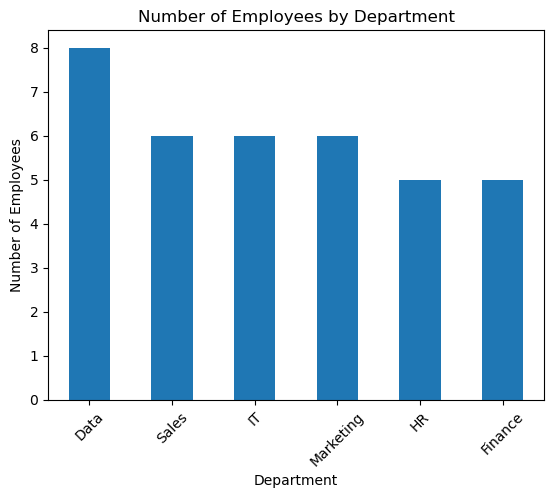

In [45]:
# Q30. Bar chart showing the number of employees in each Department

department_coutns = df["Department"].value_counts()
department_counts.plot(kind="bar")

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

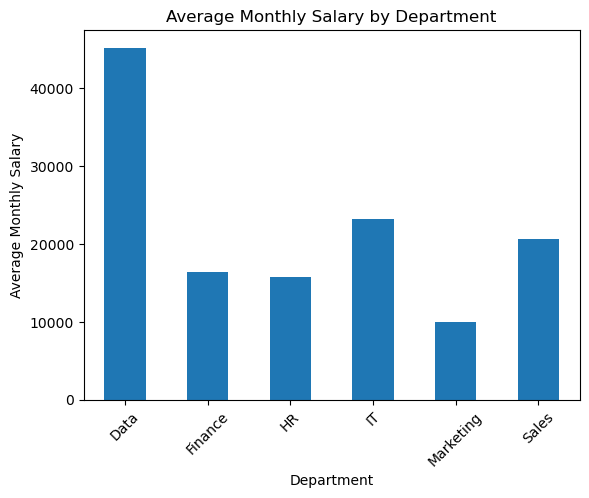

In [47]:
# Q31. Bar chart showing average Monthly_Salray by Department

avg_salary_by_department = df.groupby("Department")["Monthly_Salary"].mean()
avg_salary_by_department.plot(kind="bar")

plt.title("Average Monthly Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Salary")
plt.xticks(rotation=45)
plt.show()

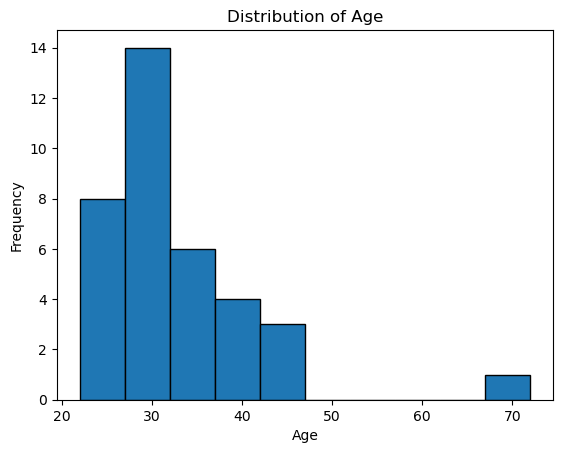

In [48]:
# Q 32. Histogram for Age 
plt.hist(df["Age"], bins = 10, edgecolor = "black")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# most employees are concentrated in the younger and middle-age ranges, while a much older age value apperas separtaely from the majority of the data. 
# The age distribution is right-skewed. Most employees are between their 20s and 40s, while the age of 72 appears to be an extreme outlier 
# The salary distribution is strongly right-skewed because most salaries are much lower than the maximum value. The histogram suggests the presence of an extreme salary outlier. 


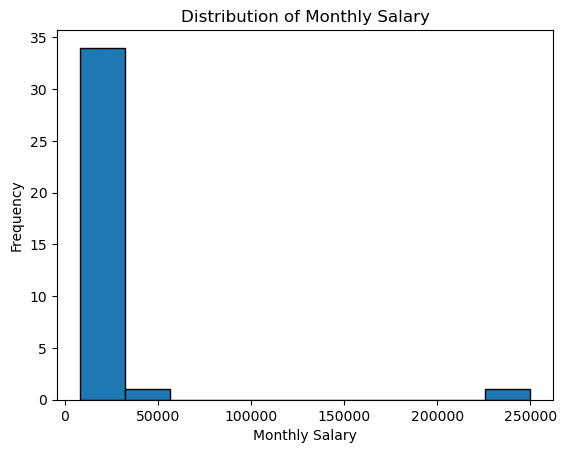

In [49]:
# Q33. Histogram for Monthly_Salary 
plt.hist(df["Monthly_Salary"], bins=10, edgecolor="black")

plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.show()


# The Monthly_salary distribution is strongly-right skewed. Most salaries are below 50,000 while the value of 250,00 is an extreme outlier 

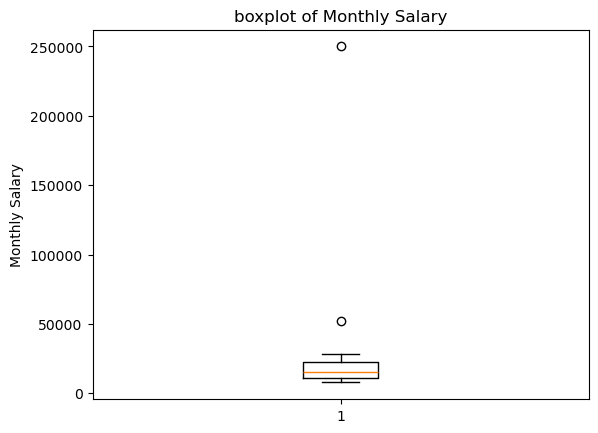

In [50]:
# Q34. Boxplot for Monthly_Salary
plt.boxplot(df["Monthly_Salary"])

plt.title("boxplot of Monthly Salary")
plt.ylabel("Monthly Salary")
plt.show()

# The boxplot identifies approximately 52,000 and 250,000 as unusually high salary values. The 250,000 salary is especially extreme compared with the rest of the dataset. 

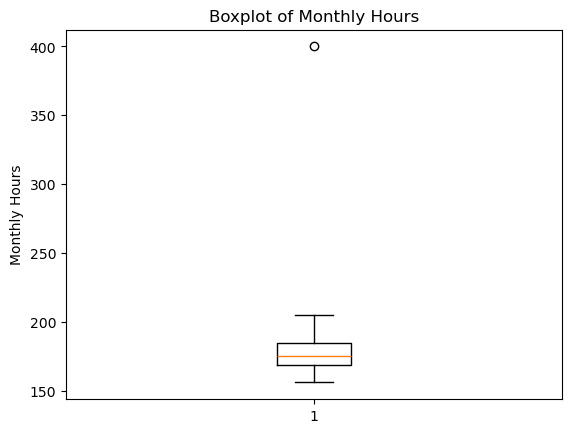

In [52]:
# Q35. Boxplot for Monthly_Hours

plt.boxplot(df["Monthly_Hours"])

plt.title("Boxplot of Monthly Hours")
plt.ylabel("Monthly Hours")
plt.show()

# The Monthly_Hours boxplot shows 400 hours as a clear extreme outlier, while most employees have monthly hours between approximately 160 and 200. 

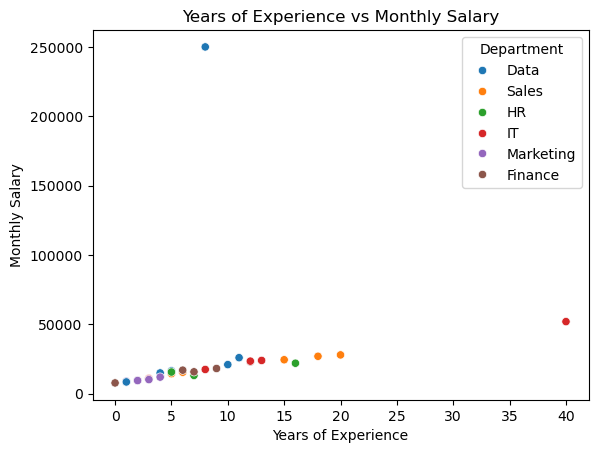

In [53]:
# Q 36. Scatter plot of Years_Experience vs Monthly_Salary

sns.scatterplot(
    data=df,
    x="Years_Experience",
    y="Monthly_Salary",
    hue="Department"
)

plt.title("Years of Experience vs Monthly Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Monthly Salary")
plt.show()

# Monthly salary generally tends to increase with years of experience. However, the extreme salary value of 250,000 is far from the main pattern and may distort the relationship. 

Correlation Matrix:


,Employee_ID,Age,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience
Employee_ID,1.000000,0.090848,0.096806,0.221007,-0.055963,0.217035,0.230528
Age,0.090848,1.000000,0.997815,0.219378,0.472127,0.185113,-0.154954
Years_Experience,0.096806,0.997815,1.000000,0.210221,0.463678,0.176357,-0.159568
Monthly_Salary,0.221007,0.219378,0.210221,1.000000,0.453437,0.036923,0.905689
Performance_Score,-0.055963,0.472127,0.463678,0.453437,1.000000,0.106530,0.185084
Monthly_Hours,0.217035,0.185113,0.176357,0.036923,0.106530,1.000000,-0.064138
Salary_Per_Year_Experience,0.230528,-0.154954,-0.159568,0.905689,0.185084,-0.064138,1.000000


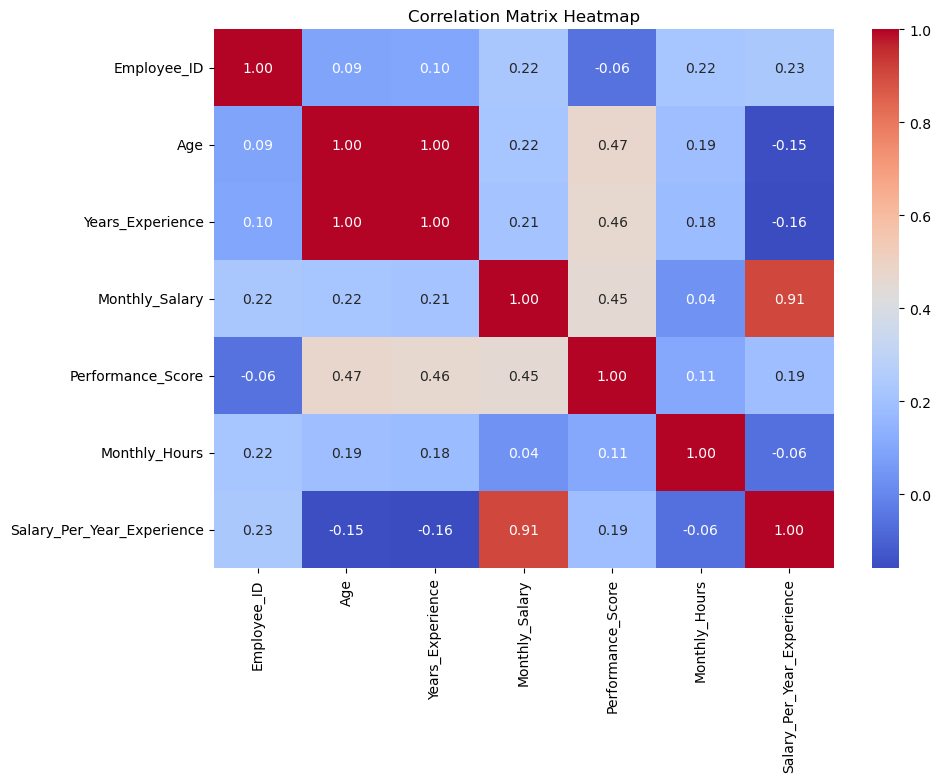

In [54]:
# Q37. Correlation matrix for numerical columns

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.show()

                        

In [56]:
# Q38. Find the two numerical variables with the strongest positvie correlation

corr_matrix = numeric_df.corr()

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

strongest_pair = corr_pairs.index[0]
strongest_value = corr_pairs.iloc[0]

print("Strongest positive correlation:")
print(strongest_pair)
print("Correlation value:", strongest_value)

# The two numerical variables with the strongest positive correlation are Age and Years_Experience, with a correlation of approximately 0.998, meaning that Years_Experience
# tends to increase as Age increases. 

Strongest positive correlation:
('Age', 'Years_Experience')
Correlation value: 0.9978153974978691


In [ ]:
# Q39. Nominal and Ordinal Categorical Columns 

# Nominal Columns: City, Department, Gender, Name
# There are nominal because their categories do not have a natural ranking or order.
# ORdinal columns: Experience_Level, Education_Level. 
# These are ordinal because their categories have a logical order. Experience_Level follows Junior < Mid < Senior, and Education_Level follows 
# Bachelor < Master < PhD

In [57]:
# Q40. One-Hot Encoding for nominal columns

nominal_columns = ["City", "Department", "Gender"]

df_encoded =pd.get_dummies(
    df,
    columns=nominal_columns,
    drop_first=False
)

print("First 5 rows after One-Hot Encoding:")
df_encoded.head()

First 5 rows after One-Hot Encoding:


,Employee_ID,Name,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,1001,Sara,23,Bachelor,Junior,1,8500.0,7.8,160.0,4250.000000,...,False,False,True,False,False,False,False,False,True,False
1,1002,Omar,29,Master,Mid,5,14500.0,8.1,172.0,2416.666667,...,False,False,False,False,False,False,False,True,False,True
2,1003,Lina,31,Bachelor,Mid,7,13200.0,7.5,168.0,1650.000000,...,False,False,False,False,True,False,False,False,True,False
3,1004,Youssef,27,Bachelor,Junior,3,11000.0,8.7,180.0,2750.000000,...,True,False,False,False,False,True,False,False,False,True
4,1005,Nour,35,Master,Senior,10,21000.0,9.0,176.0,1909.090909,...,False,False,True,False,False,False,False,False,True,False


In [58]:
# Q40. Apply One-Hot Encoding to nominal columns
noimnal_columns = ["City", "Department", "Gender"]

df_encoded = pd.get_dummies(
    df,
    columns=nominal_columns,
    drop_first=False
)

print("First 5 rows after One-Hot Encoding:")
df_encoded.head()

First 5 rows after One-Hot Encoding:


,Employee_ID,Name,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,1001,Sara,23,Bachelor,Junior,1,8500.0,7.8,160.0,4250.000000,...,False,False,True,False,False,False,False,False,True,False
1,1002,Omar,29,Master,Mid,5,14500.0,8.1,172.0,2416.666667,...,False,False,False,False,False,False,False,True,False,True
2,1003,Lina,31,Bachelor,Mid,7,13200.0,7.5,168.0,1650.000000,...,False,False,False,False,True,False,False,False,True,False
3,1004,Youssef,27,Bachelor,Junior,3,11000.0,8.7,180.0,2750.000000,...,True,False,False,False,False,True,False,False,False,True
4,1005,Nour,35,Master,Senior,10,21000.0,9.0,176.0,1909.090909,...,False,False,True,False,False,False,False,False,True,False


In [59]:
# Q41. Apply Ordinal Encoding to Experience_Level

experience_mapping = {
    "Junior": 0,
    "Mid": 1,
    "Senior": 2
} 

df_encoded["Experience_Level"] = df_encoded["Experience_Level"].map(experience_mapping)

print("Encoded Experience_Level:")
df_encoded[["Name", "Experience_Level"]].head(10)

Encoded Experience_Level:


,Name,Experience_Level
0,Sara,0
1,Omar,1
2,Lina,1
3,Youssef,0
4,Nour,2
5,Karim,2
6,Mariam,0
7,Ahmed,1
8,Hana,1
9,Mostafa,2


In [61]:
# Q42. Apply Original Encoding to Education_Level

education_mapping = {
    "Bachelor": 0,
    "Master": 1,
    "PhD": 2
}

df_encoded["Education_Level"] = df_encoded["Education_Level"].map(education_mapping)

print("Encoded Education_Level:")
print(df_encoded[["Name", "Education_Level"]].head(10))

# Education_Level is treated as ordinal becasue the categories follow a logical order: Bachelor< Master< PhD

Encoded Education_Level:


,Name,Education_Level
0,Sara,0
1,Omar,1
2,Lina,0
3,Youssef,0
4,Nour,1
5,Karim,0
6,Mariam,0
7,Ahmed,1
8,Hana,0
9,Mostafa,1


In [62]:
# Q43. Dispaly transformed feature names and first 5 transformed rows.
print("Transformed Feature Names:")
print(df_encoded.columns.tolist())

print("\nFirst 5 Transformed Rows:")
df_encoded.head()

Transformed Feature Names:
['Employee_ID', 'Name', 'Age', 'Education_Level', 'Experience_Level', 'Years_Experience', 'Monthly_Salary', 'Performance_Score', 'Monthly_Hours', 'Salary_Per_Year_Experience', 'City_Alexandria', 'City_Cairo', 'City_Giza', 'City_Mansoura', 'Department_Data', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Gender_F', 'Gender_M']

First 5 Transformed Rows:


,Employee_ID,Name,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,1001,Sara,23,0,0,1,8500.0,7.8,160.0,4250.000000,...,False,False,True,False,False,False,False,False,True,False
1,1002,Omar,29,1,1,5,14500.0,8.1,172.0,2416.666667,...,False,False,False,False,False,False,False,True,False,True
2,1003,Lina,31,0,1,7,13200.0,7.5,168.0,1650.000000,...,False,False,False,False,True,False,False,False,True,False
3,1004,Youssef,27,0,0,3,11000.0,8.7,180.0,2750.000000,...,True,False,False,False,False,True,False,False,False,True
4,1005,Nour,35,1,2,10,21000.0,9.0,176.0,1909.090909,...,False,False,True,False,False,False,False,False,True,False


In [65]:
# Q44. Apply StandardScaler to numerical features

from sklearn.preprocessing import StandardScaler
feature_to_scale = ["Age", "Years_Experience", "Monthly_Salary"]

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df_encoded[feature_to_scale]
)

standard_scaled_df = pd.DataFrame(
    standard_scaled,
    columns=feature_to_scale
)

print("First 5 Standard-Scaled Rows:")
print(standard_scaled_df.head())

First 5 Standard-Scaled Rows:


,Age,Years_Experience,Monthly_Salary
0,-1.030678,-0.916968,-0.382442
1,-0.360116,-0.373580,-0.229210
2,-0.136596,-0.101885,-0.262410
3,-0.583637,-0.645274,-0.318595
4,0.310445,0.305656,-0.063208


In [67]:
# Q45. Check the mean and standard deviation of scaled features

print("Mean of Standard-Scaled Features:")
print(standard_scaled_df.mean())

print("\nStandard Deviation of Standard-Scaled Features:")
print(standard_scaled_df.std(ddof=0))

# The mean of each Standard -Scaled feature is approximately 0, and the standard deviation is 1. This confirms that StandardScaler worked correctly. 

Mean of Standard-Scaled Features:


Age                 6.476301e-17
Years_Experience    9.251859e-18
Monthly_Salary      4.625929e-18
dtype: float64


Standard Deviation of Standard-Scaled Features:


Age                 1.0
Years_Experience    1.0
Monthly_Salary      1.0
dtype: float64

In [69]:
# Q46. Apply MinMaxScaler to hte same numerical features

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled =minmax_scaler.fit_transform(
    df_encoded[feature_to_scale]
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled,
    columns=feature_to_scale
)

print("First 5 MinMax-Scaled Rows:")
print(minmax_scaled_df.head())

First 5 MinMax-Scaled Rows:


,Age,Years_Experience,Monthly_Salary
0,0.02,0.025,0.002890
1,0.14,0.125,0.027663
2,0.18,0.175,0.022296
3,0.10,0.075,0.013212
4,0.26,0.250,0.054500


In [72]:
# Q47. Check minimum and maximu mvalues

print("Minimum values:")
print(minmax_scaled_df.min())

print("\nMaximum values:")
print(minmax_scaled_df.max())

# After MinMaxScaler, the minimum value of each selected feature is 0 and the maximum value is 1. This confirms that the features were scaled to the expected range of 0 to 1.
# This confirms that MinMaxScaler successfully transformed the selected nuemrical features into the expcted range of 0 to 1. 

Minimum values:


Age                 0.0
Years_Experience    0.0
Monthly_Salary      0.0
dtype: float64


Maximum values:


Age                 1.0
Years_Experience    1.0
Monthly_Salary      1.0
dtype: float64

In [76]:
# Q49. Calculate Q1, Q3, and IQR for Monthly_Salary

Q1_salary = df["Monthly_Salary"].quantile(0.25)
Q3_salary = df["Monthly_Salary"].quantile(0.75)

IQR_salary = Q3_salary - Q1_salary

print("Q1:", Q1_salary)
print("Q2:", Q3_salary)
print("IQR:", IQR_salary)

Q1: 10950.0
Q2: 22250.0
IQR: 11300.0


In [77]:
# Q50. Calculate lower and upper IQR bounds for Monthly_Salary

lower_bound_salary = Q1_salary - 1.5 * IQR_salary
upper_bound_salary = Q3_salary + 1.5 * IQR_salary

print("Lower Bound:", lower_bound_salary)
print("Upper Bound:", upper_bound_salary)

Lower Bound: -6000.0
Upper Bound: 39200.0


In [79]:
# Q51. Display Monthly_Salary outliers

salary_outliers = df[
    (df["Monthly_Salary"] < lower_bound_salary) |
    (df["Monthly_Salary"] > upper_bound_salary)
]

print("Monthly Salary Outliers:")
salary_outliers[["Employee_ID", "Name", "Monthly_Salary"]]

Monthly Salary Outliers:


,Employee_ID,Name,Monthly_Salary
29,1030,Adel,52000.0
30,1031,Laila,250000.0


In [84]:
# Q52. Detect outliers in Age using IQR

Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age 

age_outliers = df[
    (df["Age"] < lower_bound_age) |
    (df["Age"] > upper_bound_age)
]

print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower Bound:", lower_bound_age)
print("Upper Bound:", upper_bound_age)

print("\nAge Outliers:")
age_outliers[["Employee_ID", "Name", "Age"]]

Q1: 27.0
Q3: 35.25
IQR: 8.25
Lower Bound: 14.625
Upper Bound: 47.625

Age Outliers:


,Employee_ID,Name,Age
29,1030,Adel,72


In [87]:
# Q 53. Detect outliers in Monthly_Hours using IQR

Q1_hours = df["Monthly_Hours"].quantile(0.25)
Q3_hours = df["Monthly_Hours"].quantile(0.75)

IQR_hours = Q3_hours - Q1_hours

lower_bound_hours = Q1_hours - 1.5 * IQR_hours
upper_bound_hours = Q3_hours + 1.5 * IQR_hours

hours_outliers = df[
    (df["Monthly_Hours"] < lower_bound_hours) |
    (df["Monthly_Hours"] > upper_bound_hours)
]

print("Q1:", Q1_hours)
print("Q3:", Q3_hours)
print("IQR:", IQR_hours)
print("Lower Bound:", lower_bound_hours)
print("Upper Bound:", upper_bound_hours)

print("\nMonthly Hours Outliers:")
hours_outliers[["Employee_ID", "Name", "Monthly_Hours"]]

Q1: 168.75
Q3: 184.5
IQR: 15.75
Lower Bound: 145.125
Upper Bound: 208.125

Monthly Hours Outliers:


,Employee_ID,Name,Monthly_Hours
31,1032,Fady,400.0


In [91]:
# Q54. Create a reusable function to find outliers using IQR
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers =df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
        ]
    return outliers

# Test the function with Monthly_Salary

salary_outliers_function = find_outliers_iqr(df, "Monthly_Salary")

print("Monthly Salary Outliers:")
salary_outliers_function[["Employee_ID", "Name", "Monthly_Salary"]]

Monthly Salary Outliers:


,Employee_ID,Name,Monthly_Salary
29,1030,Adel,52000.0
30,1031,Laila,250000.0


In [96]:
# Q55. Create a reusable function to remove outliers using IQR

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

    return cleaned_df

    cleaned_salary_df = remove_outliers_iqr(df, "Monthy_Salary")

    print("Rows before removing outliers:", len(df))
    print("Rows after removing salary outliers:", len(cleaned_salary_df))

    cleaned_salary_df[["Employee_ID", "Name", "Monthly_Salary"]].head(10)


    print("Maximum salary after outlier removal:")
    print(cleaned_salary_df["Monthly_Salary"].max())

In [97]:
# Q56. Remove outliers from Monthly_Salary using IQR

salary_cleaned_df = remove_outliers_iqr(df, "Monthly_Salary")

print("Rows before removal:", len(df))
print("Rows after Monthly_Salray outlier removal:", len(salary_cleaned_df))

salary_cleaned_df[["Employee_ID", "Name", "Monthly_Salary"]].head()

Rows before removal: 36
Rows after Monthly_Salray outlier removal: 34


,Employee_ID,Name,Monthly_Salary
0,1001,Sara,8500.0
1,1002,Omar,14500.0
2,1003,Lina,13200.0
3,1004,Youssef,11000.0
4,1005,Nour,21000.0


In [100]:
# Q57. Remove outliers from Age and Monthly_Hours

outlier_removed_df = remove_outliers_iqr(salary_cleaned_df, "Age")
outlier_removed_df = remove_outliers_iqr(outlier_removed_df, "Monthly_Hours")

print("Rows before all outlier removal:", len(df))
print("Rows after all outlier removal:", len(outlier_removed_df))
print("Maximum Age after removal:", outlier_removed_df["Age"].max())
print("Maximum Monthly_Hours after removal:", outlier_removed_df["Monthly_Hours"].max())
print("Maximum Monthly_Salray after removal:", outlier_removed_df["Monthly_Salary"].max())

Rows before all outlier removal: 36
Rows after all outlier removal: 33
Maximum Age after removal: 45
Maximum Monthly_Hours after removal: 198.0
Maximum Monthly_Salray after removal: 28000.0


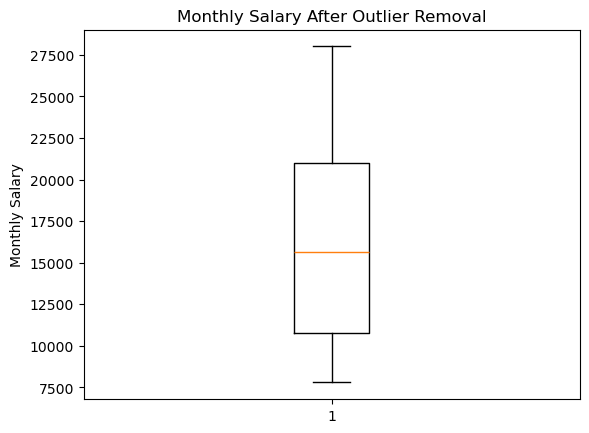

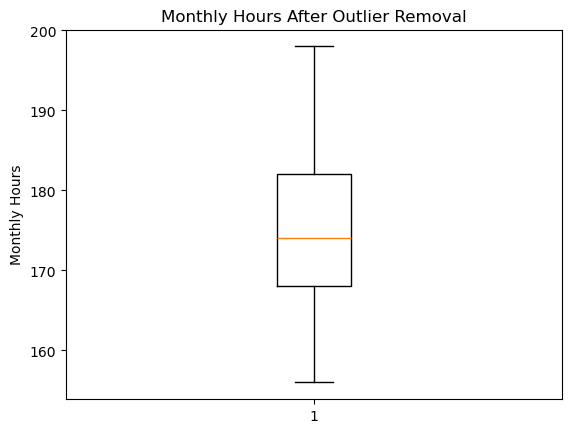

In [103]:
# Q58. boxplot for Monthly_Salary after outlier removed

plt.boxplot(outlier_removed_df["Monthly_Salary"])

plt.title("Monthly Salary After Outlier Removal")
plt.ylabel("Monthly Salary")
plt.show()

# Q58. Boxplot for Monthly_Hours after outlier removal

plt.boxplot(outlier_removed_df["Monthly_Hours"])

plt.title("Monthly Hours After Outlier Removal")
plt.ylabel("Monthly Hours")
plt.show()

# After outlier removal, the boxplots show a much tighter distribution. The extreme values that were previously far from the main data range are no longer present. 

In [104]:
# Q59. Recalculate average salray by Department after outlier removal

avg_salary_before = df.groupby("Department")["Monthly_Salary"].mean()
avg_salary_after = outlier_removed_df.groupby("Department")["Monthly_Salary"].mean()

comparison = pd.DataFrame({
    "Before_Outlier_Removal": avg_salary_before, 
    "After_Outlier_Removal": avg_salary_after
})

print("Average Salary by Department Before and After Outlier Removal:")
comparison

# The average salary for the Dat adepartment decreases substantially after outlier removal because the extreme salary value of 250,000 had strongly increased the oirginal 
# departmental average. 

Average Salary by Department Before and After Outlier Removal:


,Before_Outlier_Removal,After_Outlier_Removal
Department,,
Data,45187.500000,15928.571429
Finance,16360.000000,16360.000000
HR,15800.000000,15800.000000
IT,23133.333333,17360.000000
Marketing,10000.000000,9600.000000
Sales,20666.666667,20666.666667


In [106]:
# Q60. Create the final cleaned DataFrame

final_cleaned_df = outlier_removed_df.copy()

# Original Encoding 
experience_mapping = {
    "Junior": 0,
    "Mid": 1,
    "Senior": 2
}

education_mapping = {
    "Bachelor": 0,
    "Master": 1,
    "PhD": 2
}

final_cleaned_df["Experience_Level"] = (
    final_cleaned_df["Experience_Level"].map(experience_mapping)
)

final_cleaned_df["Education_Level"] = (
    final_cleaned_df["Education_Level"].map(education_mapping)
)

#One-Hot Encoding

final_cleaned_df = pd.get_dummies(
    final_cleaned_df, 
    columns=["City", "Department", "Gender"],
    drop_first=False
)

# Name is an identifier-like text column, so remove it for ML use
final_cleaned_df = final_cleaned_df.drop(columns=["Name"])

print("Final Cleaned DataFrame:")
print(final_cleaned_df.head())

print("\nShape:", final_cleaned_df.shape)
                                             


Final Cleaned DataFrame:


,Employee_ID,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,City_Alexandria,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,1001,23,0,0,1,8500.0,7.8,160.0,4250.000000,False,...,False,False,True,False,False,False,False,False,True,False
1,1002,29,1,1,5,14500.0,8.1,172.0,2416.666667,True,...,False,False,False,False,False,False,False,True,False,True
2,1003,31,0,1,7,13200.0,7.5,168.0,1650.000000,False,...,False,False,False,False,True,False,False,False,True,False
3,1004,27,0,0,3,11000.0,8.7,180.0,2750.000000,False,...,True,False,False,False,False,True,False,False,False,True
4,1005,35,1,2,10,21000.0,9.0,176.0,1909.090909,False,...,False,False,True,False,False,False,False,False,True,False



Shape: (33, 21)


In [107]:
print(final_cleaned_df.columns.tolist())

['Employee_ID', 'Age', 'Education_Level', 'Experience_Level', 'Years_Experience', 'Monthly_Salary', 'Performance_Score', 'Monthly_Hours', 'Salary_Per_Year_Experience', 'City_Alexandria', 'City_Cairo', 'City_Giza', 'City_Mansoura', 'Department_Data', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Gender_F', 'Gender_M']


In [109]:
# Q61. Create StandardScaler and MinMaxScaler versions

from sklearn.preprocessing import StandardScaler, MinMaxScaler

numeric_columns = final_cleaned_df.select_dtypes(
    include=["int64", "float64"]
).columns

# StandardScaler version
standard_scaler = StandardScaler()
final_standard_df = final_cleaned_df.copy()

final_standard_df[numeric_columns] = standard_scaler.fit_transform(
    final_cleaned_df[numeric_columns]
)

# MinMaxScaler version
minmax_scaler = MinMaxScaler()
final_minmax_df = final_cleaned_df.copy()

final_minmax_df[numeric_columns] = minmax_scaler.fit_transform(
    final_cleaned_df[numeric_columns]
)

print("StandardScaler Version:")
print(final_standard_df.head())

print("\nMinMaxScaler Version:")
print(final_minmax_df.head())

StandardScaler Version:


,Employee_ID,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,City_Alexandria,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,-1.618887,-1.324042,-0.818317,-1.278977,-1.143951,-1.292575,-0.545933,-1.364139,1.354222,False,...,False,False,True,False,False,False,False,False,True,False
1,-1.519955,-0.345832,0.981981,0.039968,-0.365592,-0.271307,-0.040817,-0.268401,-0.155035,True,...,False,False,False,False,False,False,False,True,False,True
2,-1.421023,-0.019762,-0.818317,0.039968,0.023587,-0.492582,-1.051048,-0.633647,-0.786179,False,...,False,False,False,False,True,False,False,False,True,False
3,-1.322091,-0.671902,-0.818317,-1.278977,-0.754772,-0.867047,0.969413,0.462092,0.119375,False,...,True,False,False,False,False,True,False,False,False,True
4,-1.223159,0.632378,0.981981,1.358913,0.607355,0.835067,1.474528,0.096846,-0.572888,False,...,False,False,True,False,False,False,False,False,True,False



MinMaxScaler Version:


,Employee_ID,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience,City_Alexandria,...,City_Giza,City_Mansoura,Department_Data,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,0.000000,0.043478,0.0,0.0,0.05,0.034653,0.347826,0.095238,0.454340,False,...,False,False,True,False,False,False,False,False,True,False
1,0.028571,0.304348,0.5,0.5,0.25,0.331683,0.478261,0.380952,0.172544,True,...,False,False,False,False,False,False,False,True,False,True
2,0.057143,0.391304,0.0,0.5,0.35,0.267327,0.217391,0.285714,0.054702,False,...,False,False,False,False,True,False,False,False,True,False
3,0.085714,0.217391,0.0,0.0,0.15,0.158416,0.739130,0.571429,0.223779,False,...,True,False,False,False,False,True,False,False,False,True
4,0.114286,0.565217,0.5,1.0,0.50,0.653465,0.869565,0.476190,0.094526,False,...,False,False,True,False,False,False,False,False,True,False


In [110]:
# Q62. Verify the final dataset

print("Shape:")
print(final_cleaned_df.shape)

print("\nMissing Values:")
print(final_cleaned_df.isnull().sum())

print("\nDuplicate Rows:")
print(final_cleaned_df.duplicated().sum())

print("\nDat Types:")
print(final_cleaned_df.dtypes)

print("\nSummary Statistics:")
print(final_cleaned_df.describe())

Shape:
(33, 21)

Missing Values:


Employee_ID                   0
Age                           0
Education_Level               0
Experience_Level              0
Years_Experience              0
Monthly_Salary                0
Performance_Score             0
Monthly_Hours                 0
Salary_Per_Year_Experience    0
City_Alexandria               0
City_Cairo                    0
City_Giza                     0
City_Mansoura                 0
Department_Data               0
Department_Finance            0
Department_HR                 0
Department_IT                 0
Department_Marketing          0
Department_Sales              0
Gender_F                      0
Gender_M                      0
dtype: int64


Duplicate Rows:
0

Dat Types:


Employee_ID                     int64
Age                             int64
Education_Level                 int64
Experience_Level                int64
Years_Experience                int64
Monthly_Salary                float64
Performance_Score             float64
Monthly_Hours                 float64
Salary_Per_Year_Experience    float64
City_Alexandria                  bool
City_Cairo                       bool
City_Giza                        bool
City_Mansoura                    bool
Department_Data                  bool
Department_Finance               bool
Department_HR                    bool
Department_IT                    bool
Department_Marketing             bool
Department_Sales                 bool
Gender_F                         bool
Gender_M                         bool
dtype: object


Summary Statistics:


,Employee_ID,Age,Education_Level,Experience_Level,Years_Experience,Monthly_Salary,Performance_Score,Monthly_Hours,Salary_Per_Year_Experience
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,1017.363636,31.121212,0.454545,0.969697,6.878788,16093.939394,8.124242,174.939394,2604.991996
std,10.264679,6.228752,0.564076,0.769937,5.218702,5966.138271,0.603133,11.121318,1233.559266
min,1001.000000,22.000000,0.000000,0.000000,0.000000,7800.000000,7.000000,156.000000,1294.117647
25%,1009.000000,27.000000,0.000000,0.000000,3.000000,10800.000000,7.700000,168.000000,1820.000000
50%,1017.000000,29.000000,0.000000,1.000000,5.000000,15650.000000,8.200000,174.000000,2416.666667
75%,1025.000000,35.000000,1.000000,2.000000,10.000000,21000.000000,8.600000,182.000000,2750.000000
max,1036.000000,45.000000,2.000000,2.000000,20.000000,28000.000000,9.300000,198.000000,7800.000000


In [111]:
# 63. Preprocessing Summary

# The raw employees dataset was first inspected to understand its structure, data types, missing values, 
# and duplicate rows. 
# Missing categorical values in City and Education_Level were filled using the mode, while missing numerical values were
# filled using the median. Duplicate rows were identified and removed. Nominal categorical variables
# such as City, Department, and Gender were transformed using One-Hot Encoding, while Experience_level and
# Education_Level were encoded using logical ordinal mappings. Numerical features were scaled using both 
# StandardScaler and MinMaxScaler. Extreme outliers in Monthly_Salary, Age, and Monthly_Hours were detected
# and treated using the iQR method. The final dataset contains no missing values or duplicate
# rows and is prepared in numerical form for machine-learning anlaysis. 

In [ ]:
# 64. Reflection

# Outlier ermoval changed the dataset most noticeably. Before outlier removal, extreme values such as a 
# Monthly_Salary of 250,000 and Monthly_Hours of 400 strongly affected the distributions and summary
# statistics. The salary histogram and boxplot were highly skewed, and the extreme salary value
# also increased the average salary of the Data department. After IQR-based outlier removal, the 
# distributions became more concentrated and the departmental salary averages become more representative of the 
# majority of employees 